# Comparison: Numerov - Whittaker
This notebook compares the Numerov method (with and without model potentials) to the Whittaker method for calculating Rydberg wavefunctions and matrix elements.

In [1]:
import logging

import matplotlib.pyplot as plt
import numpy as np

import rydstate

logging.basicConfig(level=logging.INFO, format="%(levelname)s %(filename)s: %(message)s")

## Wavefunction

In [2]:
states: dict[str, rydstate.RydbergStateSQDT] = {}

In [3]:
state = rydstate.RydbergStateSQDT("Rb", n=21, l_r=0, j_r=0.5, potential="marinescu_1993")

state.radial.integrate_wavefunction("numerov")
states["Numerov with Model Potentials"] = state

# Using Numerov without model potentials will lead to some warnings,
# since the resulting wavefunction does not pass all heuristic checks
state_without_mp = rydstate.RydbergStateSQDT(state.species, state.n, angular_ket=state.angular, potential="coulomb")
state_without_mp.radial.integrate_wavefunction("numerov")
states["Numerov without Model Potentials"] = state_without_mp

WARNING radial_ket.py: The wavefunction for the radial_ket RadialKet(nu=17.86825962895559, potential=PotentialCoulombRubidium(l_r=0)) has some issues:
      The wavefunction has 17 nodes, but should have 20 nodes.
      The integration for l=0 did stop at 0.14 (should be close to zero).


In [4]:
state_whittaker = rydstate.RydbergStateSQDT(state.species, state.n, angular_ket=state.angular)
state_whittaker.radial.create_grid_points(x_min=state.radial.x_list[0], x_max=state.radial.x_list[-1])
state_whittaker.radial.integrate_wavefunction("whittaker")
states["Whittaker"] = state_whittaker

WARNING radial_ket.py: Using Whittaker to get the wavefunction is not recommended! Use this only for comparison.


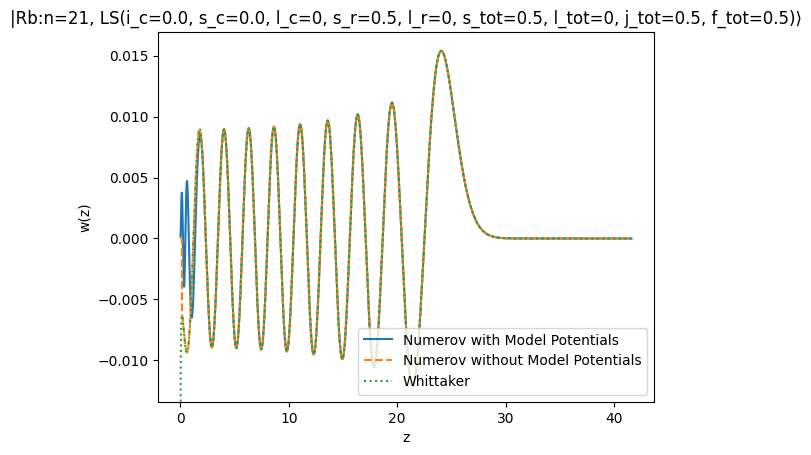

In [5]:
fig, ax = plt.subplots()
ax.set_title(str(state))

styles = ["-", "--", ":"]
for i, (label, _state) in enumerate(states.items()):
    ax.plot(_state.radial.z_list, _state.radial.w_list, ls=styles[i], label=label)
ax.legend()

ax.set_xlabel("z")
ax.set_ylabel("w(z)")

ax.set_ylim(1.1 * np.min(state.radial.w_list), 1.1 * np.max(state.radial.w_list))

plt.show()

## Radial matrix elements

In [6]:
state1 = rydstate.RydbergStateSQDT("Rb", n=10, l_r=0, j_r=0.5)
state1.radial.integrate_wavefunction("numerov")
state2 = rydstate.RydbergStateSQDT("Rb", n=9, l_r=1, j_r=1.5)
state2.radial.integrate_wavefunction("numerov")
dipole_me = state1.radial.calc_matrix_element(state2.radial, 1)
print(f"Numerov with model potentials: {dipole_me}", flush=True)

state1 = rydstate.RydbergStateSQDT("Rb", n=10, l_r=0, j_r=0.5, potential="coulomb")
state1.radial.integrate_wavefunction("numerov")
state2 = rydstate.RydbergStateSQDT("Rb", n=9, l_r=1, j_r=1.5, potential="coulomb")
state2.radial.integrate_wavefunction("numerov")
dipole_me = state1.radial.calc_matrix_element(state2.radial, 1)
print(f"Numerov without model potentials: {dipole_me}", flush=True)

state1 = rydstate.RydbergStateSQDT("Rb", n=10, l_r=0, j_r=0.5)
state1.radial.integrate_wavefunction("whittaker")
state2 = rydstate.RydbergStateSQDT("Rb", n=9, l_r=1, j_r=1.5)
state2.radial.integrate_wavefunction("whittaker")
dipole_me = state1.radial.calc_matrix_element(state2.radial, 1)
print(f"Whittaker: {dipole_me}", flush=True)

Numerov with model potentials: 43.640427394637776 bohr


WARNING radial_ket.py: The wavefunction for the radial_ket RadialKet(nu=6.864783105371448, potential=PotentialCoulombRubidium(l_r=0)) has some issues:
      The wavefunction has 6 nodes, but should have 9 nodes.
      The integration for l=0 did stop at 0.14 (should be close to zero).
WARNING radial_ket.py: The wavefunction for the radial_ket RadialKet(nu=6.350837333725099, potential=PotentialCoulombRubidium(l_r=1)) has some issues:
      The wavefunction has 5 nodes, but should have 7 nodes.


Numerov without model potentials: 43.60588874251322 bohr


WARNING radial_ket.py: Using Whittaker to get the wavefunction is not recommended! Use this only for comparison.
WARNING radial_ket.py: Using Whittaker to get the wavefunction is not recommended! Use this only for comparison.


Whittaker: 43.561313364176684 bohr
